# Lab 8: Custom CNN Model for Corn Leaf Image Classification

**Student Name:** Samiullah Khan  
**Registration Number:** 22JZELE0492  
**Course:** Machine Learning Lab  
**Supervisor:** Engr. Irshad Ullah  
**University:** UET Peshawar - Nowshera Campus  

## Lab Overview
This notebook builds and trains a custom Convolutional Neural Network for corn leaf image classification. It uses TensorFlow/Keras, `ImageDataGenerator`, model checkpoints, training-history plots, and classification metrics for evaluation.

## Learning Objectives
- Import TensorFlow/Keras layers, models, optimizers, and image preprocessing tools.
- Load images from train, validation, and test directories using `ImageDataGenerator`.
- Build and compile a custom CNN model for multi-class image classification.
- Train the CNN model and monitor validation performance using checkpoints.
- Evaluate the trained model using accuracy, a confusion matrix, and a classification report.

## Section 1: Library Import and Path Setup
This section imports Keras, plotting, NumPy, and evaluation libraries, then defines checkpoint and dataset paths.


## Lab Task

Build and train a custom CNN with the following structure:

- `Conv2D(64 filters, (3 x 3), ReLU)` -> `BatchNormalization` -> `MaxPooling2D(2 x 2)`
- `Conv2D(128 filters, (3 x 3), ReLU)` -> `BatchNormalization` -> `MaxPooling2D(2 x 2)`
- `Conv2D(256 filters, (3 x 3), ReLU)` -> `Dropout(0.3)` -> `MaxPooling2D(2 x 2)`
- `Flatten` -> `Dense(256, ReLU)` -> `Dropout(0.5)` -> `Dense(1, Sigmoid)`

### Dataset
Use only two classes from the previous lab task.

### Compilation
Compile the model with `binary_crossentropy` loss and the `adam` optimizer.

### Training and Evaluation
Train the model and evaluate its performance.

In [1]:
# Import deep-learning, plotting, array, and evaluation libraries.
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns

In [2]:
# Define the checkpoint filename pattern for saving the best model during training.
checkpoints = r'Z:\University\8th Semester\ML Lab\Lab 7,8\\E1-cp-{epoch:04d}-loss{val_loss:.2f}.h5'

In [3]:
# Define the prepared train, validation, and test dataset folders.
train_dir = r'Z:\University\8th Semester\ML Lab\Lab 7,8\Computer vision\sectionB\train'
validation_dir = r'Z:\University\8th Semester\ML Lab\Lab 7,8\Computer vision\sectionB\validation'
test_dir = r'Z:\University\8th Semester\ML Lab\Lab 7,8\Computer vision\sectionB\test'

## Section 2: CNN Architecture Design
The following cells create the CNN model using convolution, pooling, flattening, dense, and output layers.


In [4]:
# Build a sequential CNN model for four-class corn leaf classification.
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',input_shape=(256, 256, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(4,activation='softmax'))

c:\Users\engin\.conda\envs\ml\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.summary()

Model: "sequential"

â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”³â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”³â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”“
â”ƒ Layer (type)                    â”ƒ Output Shape           â”ƒ       Param # â”ƒ
â”¡â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â•‡â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â•‡â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”©
â”‚ conv2d (Conv2D)                 â”‚ (None, 254, 254, 32)   â”‚           896 â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ max_pooling2d (MaxPooling2D)    â”‚ (None, 127, 127, 32)   â”‚             0 â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ conv2d_1 (Conv2D)               â”‚ (None, 125, 125, 64)   â”‚        18,496 â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ max_pooling2d_1 (MaxPooling2D)  â”‚ (None, 62, 62, 64)     â”‚             0 â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ conv2d_2 (Conv2D)               â”‚ (None, 60, 60, 128)    â”‚        73,856 â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ max_pooling2d_2 (MaxPooling2D)  â”‚ (None, 30, 30, 128)    â”‚             0 â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ conv2d_3 (Conv2D)               â”‚ (None, 28, 28, 128)    â”‚       147,584 â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ max_pooling2d_3 (MaxPooling2D)  â”‚ (None, 14, 14, 128)    â”‚             0 â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ flatten (Flatten)               â”‚ (None, 25088)          â”‚             0 â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ dense (Dense)                   â”‚ (None, 512)            â”‚    12,845,568 â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ dense_1 (Dense)                 â”‚ (None, 4)              â”‚         2,052 â”‚
â””â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”´â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”´â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”˜

 Total params: 13,088,452 (49.93 MB)

 Trainable params: 13,088,452 (49.93 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Compile the CNN with categorical cross-entropy for multi-class classification.
model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.RMSprop(learning_rate=1e-4),
    metrics=['accuracy']
)

In [7]:
# Rescale image pixels and load batches from the train and validation folders.
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(train_dir, target_size=(256, 256), batch_size=32,class_mode='categorical')
validation_generator = test_datagen.flow_from_directory(validation_dir,target_size=(256, 256),batch_size=32,class_mode='categorical')

Found 1600 images belonging to 4 classes.
Found 252 images belonging to 4 classes.


## Section 3: Data Generators and Model Training
This section loads image batches from folders, applies rescaling, sets checkpoints, and trains the CNN model.


In [8]:
# Save the best model checkpoint based on validation loss.
EpochCheckpoint = ModelCheckpoint(checkpoints,
                             monitor="val_loss",
                             save_best_only=True, 
                             verbose=1)
callbacks = [EpochCheckpoint]

In [9]:
# Train the model using the generated image batches.
step_size_train = train_generator.n//train_generator.batch_size

model_history = model.fit(train_generator,
                    validation_data =validation_generator,
                   steps_per_epoch=step_size_train,
                   epochs=2,
                    callbacks=callbacks)

Epoch 1/2
50/50 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 0s 1s/step - accuracy: 0.3836 - loss: 1.2835
Epoch 1: val_loss improved from None to 0.60959, saving model to Z:\University\8th Semester\ML Lab\Lab 7,8\\E1-cp-0001-loss0.61.h5



Epoch 1: finished saving model to Z:\University\8th Semester\ML Lab\Lab 7,8\\E1-cp-0001-loss0.61.h5
50/50 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 68s 1s/step - accuracy: 0.5100 - loss: 1.0955 - val_accuracy: 0.7897 - val_loss: 0.6096
Epoch 2/2
50/50 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 0s 1s/step - accuracy: 0.7046 - loss: 0.6928
Epoch 2: val_loss improved from 0.60959 to 0.43613, saving model to Z:\University\8th Semester\ML Lab\Lab 7,8\\E1-cp-0002-loss0.44.h5



Epoch 2: finished saving model to Z:\University\8th Semester\ML Lab\Lab 7,8\\E1-cp-0002-loss0.44.h5
50/50 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 61s 1s/step - accuracy: 0.7462 - loss: 0.5932 - val_accuracy: 0.7778 - val_loss: 0.4361


In [10]:
model_history.history

{'accuracy': [0.5099999904632568, 0.7462499737739563],
 'loss': [1.095519781112671, 0.5932392477989197],
 'val_accuracy': [0.7896825671195984, 0.7777777910232544],
 'val_loss': [0.609592080116272, 0.4361347556114197]}

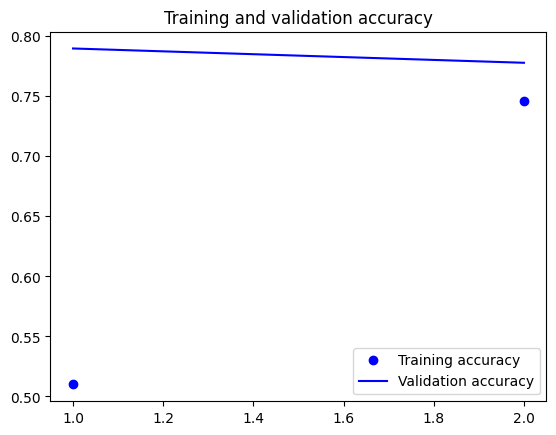

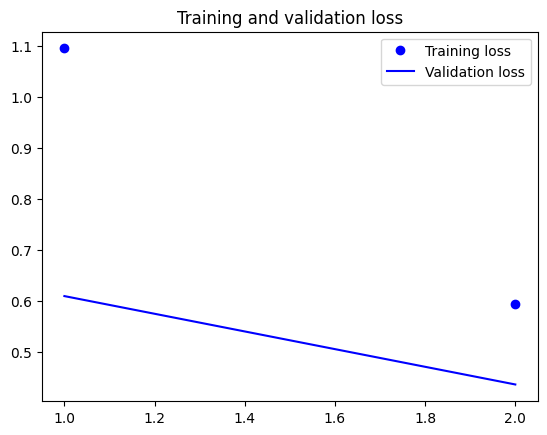

In [11]:
# Plot and save training/validation accuracy and loss curves.
acc = model_history.history['accuracy']
val_acc = model_history.history['val_accuracy']
loss = model_history.history['loss']
val_loss = model_history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure()
plt.plot(epochs, acc, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()

plt.savefig(r'Z:\University\8th Semester\ML Lab\Lab 7,8\model_Accuracy.png')

plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.savefig(r'Z:\University\8th Semester\ML Lab\Lab 7,8\model_Loss.png')

plt.show()

## Section 4: Model Evaluation and Visualization
The final cells evaluate model performance using plots, predictions, confusion matrix, and classification report.


In [12]:
# Save the trained CNN model for later use.
model.save(r'Z:\University\8th Semester\ML Lab\Lab 7,8\\E1-cp-0014-loss0.21.h5')

Found 200 images belonging to 4 classes.
7/7 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 5s 562ms/step


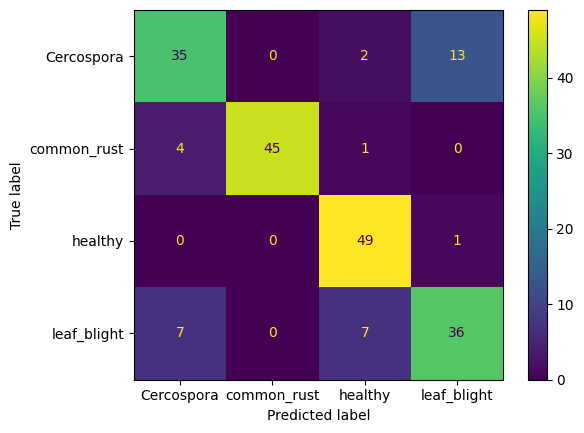

In [13]:
# Load test images, generate predictions, and display the confusion matrix.
#model = load_model(r'C:\Users\Administrator\Downloads\ML Lab\Computer vision\lab11\model_lab11.h5')
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(256, 256), batch_size=32, shuffle=False, class_mode='categorical')
label=test_generator.labels
preds=model.predict(test_generator)
pred = np.argmax(preds, axis = 1)
cm = confusion_matrix(label, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,  display_labels=['Cercospora', 'common_rust','healthy', 'leaf_blight'])
disp.plot()
plt.show()
#plt.savefig(r'Z:\University\8th Semester\ML Lab\Lab 7,8\confusion_matrics.jpg')

In [14]:
# Print precision, recall, F1-score, and support for each class.
print(classification_report(label, pred, target_names=['Cercospora', 'common_rust','healthy', 'leaf_blight']))

              precision    recall  f1-score   support

  Cercospora       0.76      0.70      0.73        50
 common_rust       1.00      0.90      0.95        50
     healthy       0.83      0.98      0.90        50
 leaf_blight       0.72      0.72      0.72        50

    accuracy                           0.82       200
   macro avg       0.83      0.82      0.82       200
weighted avg       0.83      0.82      0.82       200



## Final Conclusion
In this lab, a custom CNN was trained for corn leaf image classification using the prepared dataset. The model was evaluated using visual training curves and classification metrics.

## Submitted By
**Student Name:** Samiullah Khan  
**Registration Number:** 22JZELE0492  
**Course:** Machine Learning Lab  
**Supervisor:** Engr. Irshad Ullah  
**University:** UET Peshawar - Nowshera Campus